# Pricing and Listing Characteristics Analysis

This notebook answers: how are room type, bedroom count, and guest capacity associated with nightly pricing in Paris?

Pricing by room type
      room_type  listing_count  avg_nightly_price  avg_bedrooms  avg_guests
     Hotel room            310             386.47           1.1         2.5
Entire home/apt          43131             325.77           1.5         3.5
   Private room           4848             282.06           1.3         2.2
    Shared room            113              88.35           1.1         1.6

Highest-price segments with at least 10 listings
      room_type  bedrooms  listing_count  avg_nightly_price  avg_guests
Entire home/apt       7.0             18            3447.00        13.4
Entire home/apt       6.0             45            2360.08        12.6
   Private room       4.0             18            1691.37         5.9
Entire home/apt       5.0            186            1511.60        10.2
     Hotel room       3.0             10            1158.35         7.4
Entire home/apt       4.0            941            1112.99         8.2
   Private room       3.0             50     

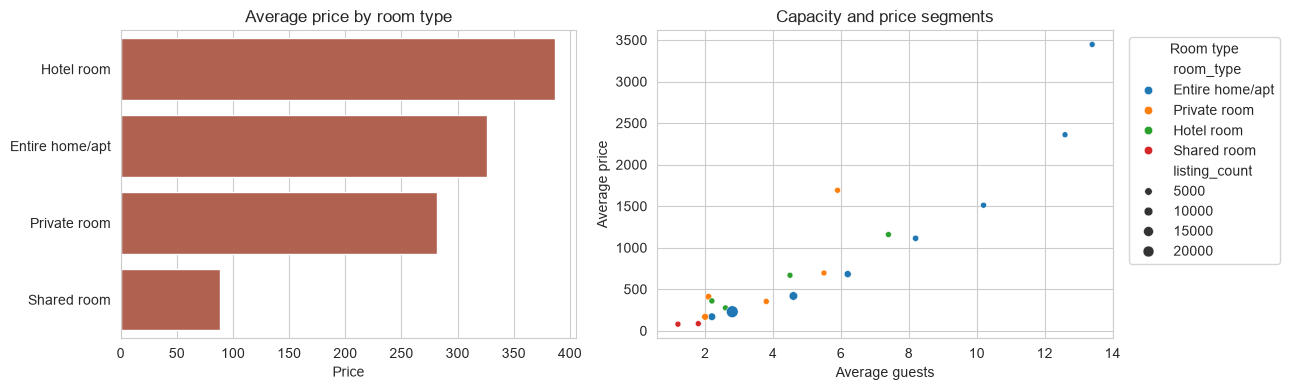

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

sns.set_style("whitegrid")
load_dotenv(Path(r"C:\Users\LENOVO\Desktop\csv-to-postgres") / ".env")
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('PGUSER', 'postgres')}:{os.getenv('PGPASSWORD', '')}@"
    f"{os.getenv('PGHOST', 'localhost')}:{os.getenv('PGPORT', '5432')}/{os.getenv('PGDATABASE', 'csv_project')}"
)

pricing = pd.read_sql(
    """
    SELECT
        room_type,
        bedrooms,
        COUNT(*) AS listing_count,
        ROUND(AVG(price), 2) AS avg_nightly_price,
        ROUND(AVG(accommodates), 1) AS avg_guests
    FROM listings_clean
    WHERE price IS NOT NULL AND price > 0
      AND room_type IS NOT NULL
    GROUP BY room_type, bedrooms
    HAVING COUNT(*) >= 10
    ORDER BY avg_nightly_price DESC
    LIMIT 20
    """,
    engine,
)

room_summary = pd.read_sql(
    """
    SELECT
        room_type,
        COUNT(*) AS listing_count,
        ROUND(AVG(price), 2) AS avg_nightly_price,
        ROUND(AVG(bedrooms), 1) AS avg_bedrooms,
        ROUND(AVG(accommodates), 1) AS avg_guests
    FROM listings_clean
    WHERE price IS NOT NULL AND price > 0 AND room_type IS NOT NULL
    GROUP BY room_type
    ORDER BY avg_nightly_price DESC
    """,
    engine,
)

print("Pricing by room type")
print(room_summary.to_string(index=False))
print("\nHighest-price segments with at least 10 listings")
print(pricing.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=room_summary, x="avg_nightly_price", y="room_type", ax=axes[0], color="#c05640")
axes[0].set_title("Average price by room type")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("")
sns.scatterplot(data=pricing, x="avg_guests", y="avg_nightly_price", size="listing_count", hue="room_type", ax=axes[1])
axes[1].set_title("Capacity and price segments")
axes[1].set_xlabel("Average guests")
axes[1].set_ylabel("Average price")
axes[1].legend(title="Room type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Analysis included
- average price by room type
- price by bedroom count and room type
- guest capacity and price segments
- minimum sample-size filtering for detailed groups